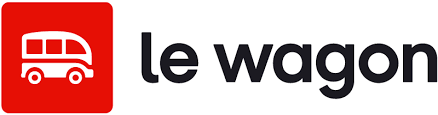

# Classification

In [ ]:
import seaborn as sns
import pandas as pd
titanic = sns.load_dataset('titanic').dropna()
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
6,0,1,male,54.0,0,0,51.8625,S,First,man,True,E,Southampton,no,True
10,1,3,female,4.0,1,1,16.7000,S,Third,child,False,G,Southampton,yes,False
11,1,1,female,58.0,0,0,26.5500,S,First,woman,False,C,Southampton,yes,True


In [ ]:
titanic.survived.value_counts(normalize=True)

survived
1    0.675824
0    0.324176
Name: proportion, dtype: float64

## Train Test Split

In [ ]:
from sklearn.model_selection import train_test_split

X = titanic[['pclass', 'who', 'age', 'fare', 'embark_town', 'deck', 'alone']]
y = titanic['survived']

X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.2,
                                                    random_state=None)

print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(145, 7) (145,)
(37, 7) (37,)


## Preprocessing

In [ ]:
X_train.head()

,pclass,who,age,fare,embark_town,deck,alone
75,3,man,25.0,7.6500,Southampton,F,True
641,1,woman,24.0,69.3000,Cherbourg,B,True
765,1,woman,51.0,77.9583,Southampton,D,False
698,1,man,49.0,110.8833,Cherbourg,C,False
453,1,man,49.0,89.1042,Cherbourg,C,False


Preprocessors

In [ ]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler

encoder = OneHotEncoder(sparse_output=False, drop='if_binary', handle_unknown='ignore').set_output(transform='pandas')
scaler = StandardScaler().set_output(transform='pandas')

Fit and transform the train set

In [ ]:
# Encoding
X_train_cat = encoder.fit_transform(X_train[['pclass', 'who', 'embark_town', 'deck', 'alone']])

# Scaling
X_train_num = scaler.fit_transform(X_train[['age', 'fare']])

# Bring it together
X_train_preproc = pd.concat([X_train_cat, X_train_num], axis=1)
X_train_preproc.head()

,pclass_1,pclass_2,pclass_3,who_child,who_man,who_woman,embark_town_Cherbourg,embark_town_Queenstown,embark_town_Southampton,deck_A,deck_B,deck_C,deck_D,deck_E,deck_F,deck_G,alone_True,age,fare
75,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,-0.605181,-0.952322
641,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,-0.667155,-0.175622
765,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.006161,-0.066540
698,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.882212,0.348267
453,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.882212,0.073882


Transform the test set

In [ ]:
# Encoding
X_test_cat = encoder.transform(X_test[['pclass', 'who', 'embark_town', 'deck', 'alone']])

# Scaling
X_test_num = scaler.transform(X_test[['age', 'fare']])

# Bring it together
X_test_preproc = pd.concat([X_test_cat, X_test_num], axis=1)
X_test_preproc.head()

,pclass_1,pclass_2,pclass_3,who_child,who_man,who_woman,embark_town_Cherbourg,embark_town_Queenstown,embark_town_Southampton,deck_A,deck_B,deck_C,deck_D,deck_E,deck_F,deck_G,alone_True,age,fare
536,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.634313,-0.714210
659,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.439984,0.378399
370,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,-0.605181,-0.350216
205,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,-2.030599,-0.916889
625,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.625908,-0.641506


## Sklearn modeling

In [ ]:
from sklearn.linear_model import LogisticRegression

# logistic regression model
clf = LogisticRegression(max_iter=1_000)
# train model
clf.fit(X_train_preproc, y_train)

# predict target
y_pred = clf.predict(X_test_preproc)
# predict probabilities
y_pred_proba = clf.predict_proba(X_test_preproc)

## Metrics

### Accuracy

In [ ]:
# accuracy on test
accuracy = clf.score(X_test_preproc, y_test)
accuracy

0.7027027027027027

Happy?

In [ ]:
# Baseline model
y_test.value_counts(normalize=True) # the majority class

survived
1    0.567568
0    0.432432
Name: proportion, dtype: float64

### Precision and recall

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score

In [ ]:
precision_score(clf.predict(X_test_preproc), y_test)

0.9523809523809523

In [ ]:
recall_score(clf.predict(X_test_preproc), y_test)

0.6666666666666666

## [Optional] Playing with the classification threshold

In [ ]:
clf.predict_proba(X_test_preproc)

array([[0.62107716, 0.37892284],
       [0.4439462 , 0.5560538 ],
       [0.21031277, 0.78968723],
       [0.08840921, 0.91159079],
       [0.65126607, 0.34873393],
       [0.54849329, 0.45150671],
       [0.57549533, 0.42450467],
       [0.01520481, 0.98479519],
       [0.02049072, 0.97950928],
       [0.44314922, 0.55685078],
       [0.46915248, 0.53084752],
       [0.05261746, 0.94738254],
       [0.02878386, 0.97121614],
       [0.05015067, 0.94984933],
       [0.07285347, 0.92714653],
       [0.02026331, 0.97973669],
       [0.40206073, 0.59793927],
       [0.41884294, 0.58115706],
       [0.0353213 , 0.9646787 ],
       [0.4407576 , 0.5592424 ],
       [0.47561117, 0.52438883],
       [0.11116101, 0.88883899],
       [0.04772131, 0.95227869],
       [0.69973419, 0.30026581],
       [0.07017662, 0.92982338],
       [0.07130989, 0.92869011],
       [0.04312902, 0.95687098],
       [0.67116458, 0.32883542],
       [0.62471101, 0.37528899],
       [0.41314583, 0.58685417],
       [0.

In [ ]:
threshold = 0.5
y_pred = clf.predict_proba(X_test_preproc)[:, 1] > threshold
y_pred

array([False,  True,  True,  True, False, False, False,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True, False,  True,  True,  True,
       False, False,  True,  True,  True,  True,  True,  True,  True,
        True])

In [ ]:
print("With threshold", threshold)
print("==================")
print("accuracy:  ", accuracy_score(y_pred, y_test))
print("precision: ", precision_score(y_pred, y_test))
print("recall:    ", recall_score(y_pred, y_test))

With threshold 0.5
accuracy:   0.7027027027027027
precision:  0.9523809523809523
recall:     0.6666666666666666


That's the same as before. Good! Now, let's change the threshold.

In [ ]:
threshold = 0.8
y_pred = clf.predict_proba(X_test_preproc)[:, 1] > threshold

print("With threshold", threshold)
print("==================")
print("accuracy:  ", accuracy_score(y_pred, y_test))
print("precision: ", precision_score(y_pred, y_test))
print("recall:    ", recall_score(y_pred, y_test))

With threshold 0.8
accuracy:   0.7567567567567568
precision:  0.7142857142857143
recall:     0.8333333333333334


We have a good recall: of all the people who survived, we detect more.

But precision went down.

In [ ]:
threshold = 0.25
y_pred = clf.predict_proba(X_test_preproc)[:, 1] > threshold

print("With threshold", threshold)
print("==================")
print("accuracy:  ", accuracy_score(y_pred, y_test))
print("precision: ", precision_score(y_pred, y_test))
print("recall:    ", recall_score(y_pred, y_test))

With threshold 0.25
accuracy:   0.5675675675675675
precision:  1.0
recall:     0.5675675675675675


Now we get a good precision: of all the people we predicted to survive, more actually survived.

But recall went down.